Sentiment Analysis of Movie Reviews — IMDb Dataset
Deep Learning Project | TensorFlow / Keras

In [7]:
# ── 0. Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)




TensorFlow version: 2.15.0


In [8]:
# ── 1. Config 
DATASET_DIR   = "aclImdb"          # path to extracted IMDb folder
BATCH_SIZE    = 32
SEED          = 42
MAX_TOKENS    = 10_000             # vocabulary size
SEQUENCE_LEN  = 250                # max review length (tokens)
EMBEDDING_DIM = 32
EPOCHS        = 10

# ── 2. Load Datasets 
raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
)

raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
)

raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    os.path.join(DATASET_DIR, "test"),
    batch_size=BATCH_SIZE,
)

print(f"\nClass names: {raw_train_ds.class_names}")   # ['neg', 'pos']

# Verify a sample batch
for text_batch, label_batch in raw_train_ds.take(1):
    print("\nSample review:", text_batch[0].numpy()[:200])
    print("Label:", label_batch[0].numpy(), "→", raw_train_ds.class_names[label_batch[0]])


Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.

Class names: ['neg', 'pos']

Sample review: b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddle'
Label: 0 → neg


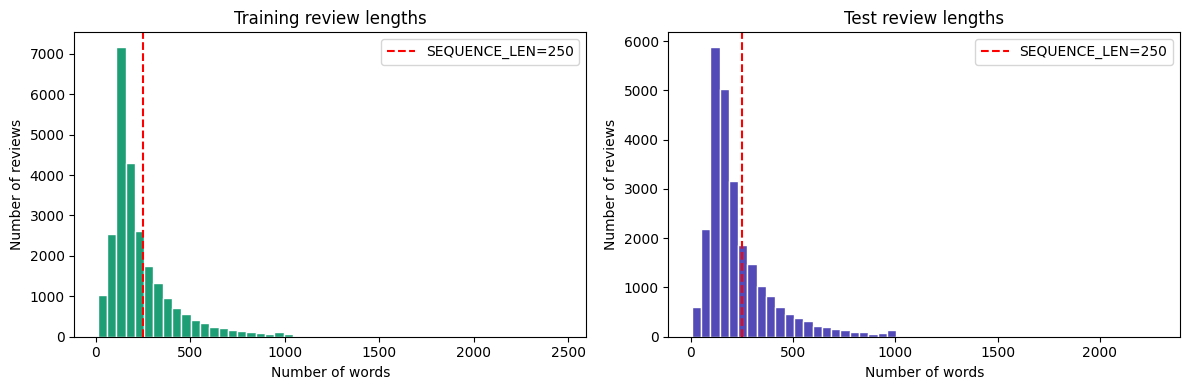

Average review length : 233 words
Max review length     : 2470 words
Min review length     : 10 words
Reviews cut by SEQUENCE_LEN=250: 7557 out of 25000


In [9]:
# ── Review Length Analysis ───────────────────────────────────
import re

def get_lengths(directory, split):
    lengths = []
    for label in ["pos", "neg"]:
        folder = os.path.join(directory, split, label)
        for fname in os.listdir(folder):
            with open(os.path.join(folder, fname), "r", encoding="utf-8") as f:
                text = f.read()
                words = len(text.split())
                lengths.append(words)
    return lengths

train_lengths = get_lengths(DATASET_DIR, "train")
test_lengths  = get_lengths(DATASET_DIR, "test")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(train_lengths, bins=50, color="#1D9E75", edgecolor="white")
plt.axvline(SEQUENCE_LEN, color="red", linestyle="--", label=f"SEQUENCE_LEN={SEQUENCE_LEN}")
plt.title("Training review lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(test_lengths, bins=50, color="#534AB7", edgecolor="white")
plt.axvline(SEQUENCE_LEN, color="red", linestyle="--", label=f"SEQUENCE_LEN={SEQUENCE_LEN}")
plt.title("Test review lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.legend()

plt.tight_layout()
plt.savefig("review_length_distribution.png", dpi=150)
plt.show()

print(f"Average review length : {int(sum(train_lengths)/len(train_lengths))} words")
print(f"Max review length     : {max(train_lengths)} words")
print(f"Min review length     : {min(train_lengths)} words")
print(f"Reviews cut by SEQUENCE_LEN={SEQUENCE_LEN}: {sum(1 for l in train_lengths if l > SEQUENCE_LEN)} out of {len(train_lengths)}")

In [10]:
# ── 3. Text Vectorisation ─────────────────────────────────────
vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LEN,
)

# Adapt ONLY on training text (no labels)
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)
    return vectorize_layer(text), label

train_ds  = raw_train_ds.map(vectorize_text)
val_ds    = raw_val_ds.map(vectorize_text)
test_ds   = raw_test_ds.map(vectorize_text)

# Cache + prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
# ── 4. Build Model ───────────────────────────────────────────
# model = keras.Sequential([
#     layers.Embedding(MAX_TOKENS + 1, EMBEDDING_DIM),   # token → dense vector
#     layers.Dropout(0.2),
#     layers.GlobalAveragePooling1D(),                    # average all token embeddings
#     layers.Dropout(0.2),
#     layers.Dense(16, activation="relu"),
#     layers.Dense(1, activation="sigmoid"),              # binary output
# ])

model = keras.Sequential([
    layers.Embedding(MAX_TOKENS + 1, EMBEDDING_DIM),    # token → dense vector
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

model.summary()

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer="adam",
    metrics=["accuracy"],
)

# ── 5. Train ─────────────────────────────────────────────────

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 32)          320032    
                                                                 
 spatial_dropout1d (Spatial  (None, None, 32)          0         
 Dropout1D)                                                      
                                                                 
 bidirectional (Bidirection  (None, None, 128)         49664     
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 64)                41216     
 onal)                                                           
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                        

In [12]:
# ── 6. Evaluate ──────────────────────────────────────────────
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy : {accuracy * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

782/782 [==============================] - 51s 65ms/step - loss: 0.3840 - accuracy: 0.8491

Test Accuracy : 84.91%
Test Loss     : 0.3840


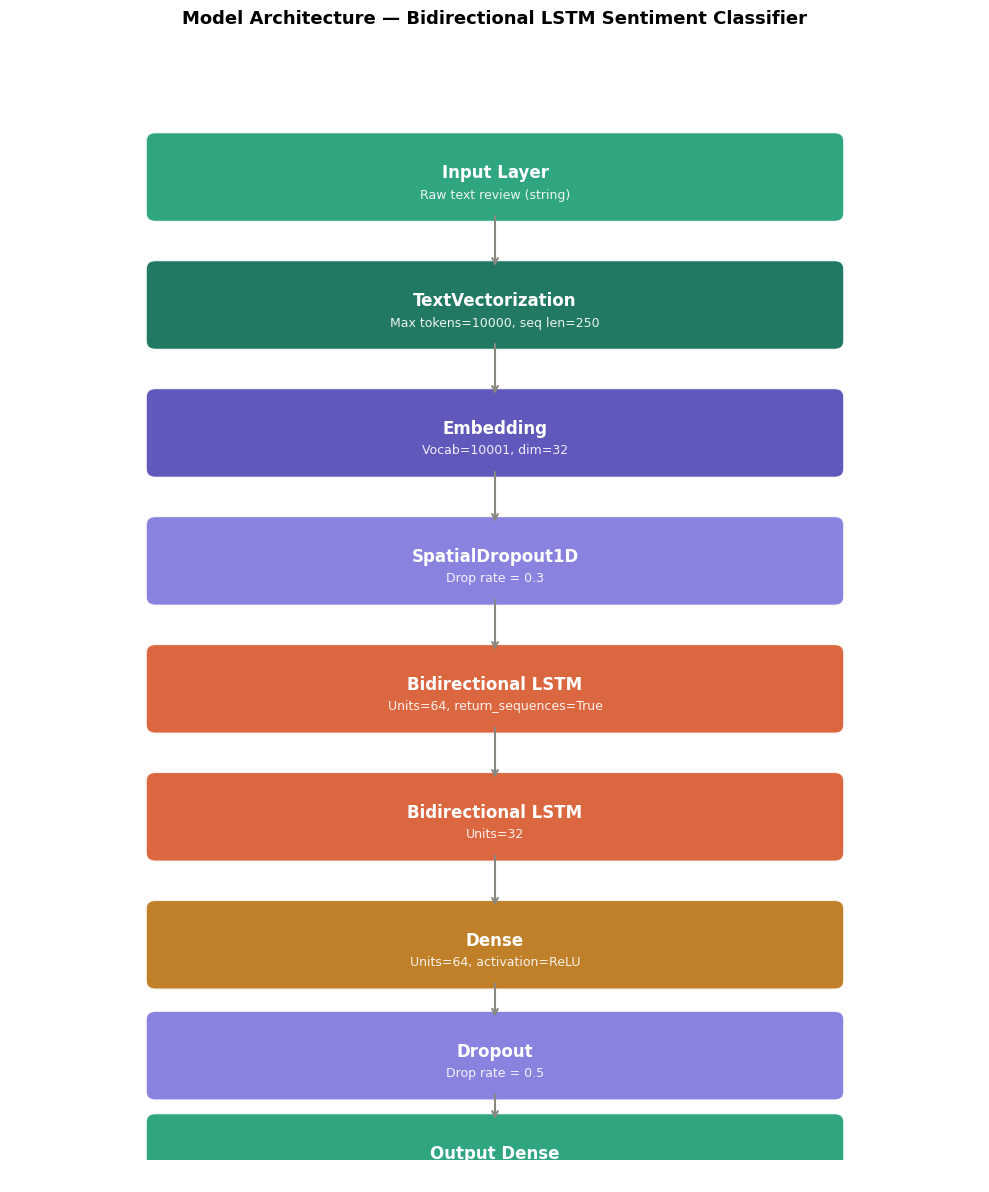

Saved: model_architecture.png


In [13]:
# ── 6.5 Model Architecture Diagram ──────────────────────────
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis("off")

layers_info = [
    ("Input Layer",              "Raw text review (string)",                      "#1D9E75", 11.5),
    ("TextVectorization",        f"Max tokens={MAX_TOKENS}, seq len={SEQUENCE_LEN}", "#0F6E56", 10.0),
    ("Embedding",                f"Vocab={MAX_TOKENS+1}, dim={EMBEDDING_DIM}",    "#534AB7", 8.5),
    ("SpatialDropout1D",         "Drop rate = 0.3",                               "#7F77DD", 7.0),
    ("Bidirectional LSTM",       "Units=64, return_sequences=True",               "#D85A30", 5.5),
    ("Bidirectional LSTM",       "Units=32",                                      "#D85A30", 4.0),
    ("Dense",                    "Units=64, activation=ReLU",                     "#BA7517", 2.5),
    ("Dropout",                  "Drop rate = 0.5",                               "#7F77DD", 1.2),
    ("Output Dense",             "Units=1, activation=Sigmoid → 0 to 1",         "#1D9E75", 0.0),
]

for name, detail, color, y in layers_info:
    # Box
    rect = mpatches.FancyBboxPatch(
        (1.5, y - 0.4), 7, 0.85,
        boxstyle="round,pad=0.1",
        facecolor=color,
        edgecolor="white",
        linewidth=1.5,
        alpha=0.92,
    )
    ax.add_patch(rect)
    # Layer name
    ax.text(5, y + 0.08, name, ha="center", va="center",
            fontsize=12, fontweight="bold", color="white")
    # Detail
    ax.text(5, y - 0.18, detail, ha="center", va="center",
            fontsize=9, color="white", alpha=0.9)
    # Arrow to next layer
    if y != 0.0:
        next_y = [l[3] for l in layers_info if l[3] < y]
        if next_y:
            ax.annotate("", xy=(5, max(next_y) + 0.45),
                        xytext=(5, y - 0.4),
                        arrowprops=dict(arrowstyle="->", color="#888780",
                                        lw=1.5))

plt.title("Model Architecture — Bidirectional LSTM Sentiment Classifier",
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("model_architecture.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_architecture.png")

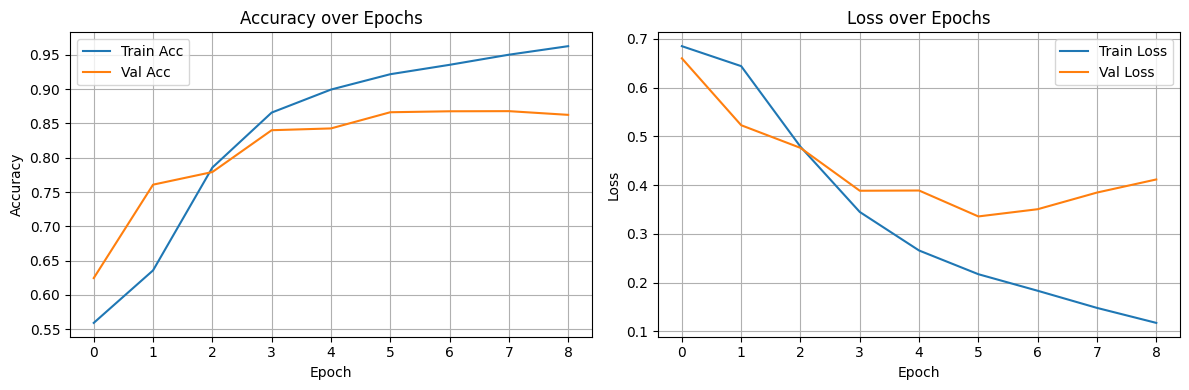

Saved: training_curves.png

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.87      0.85     12500
    Positive       0.86      0.83      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



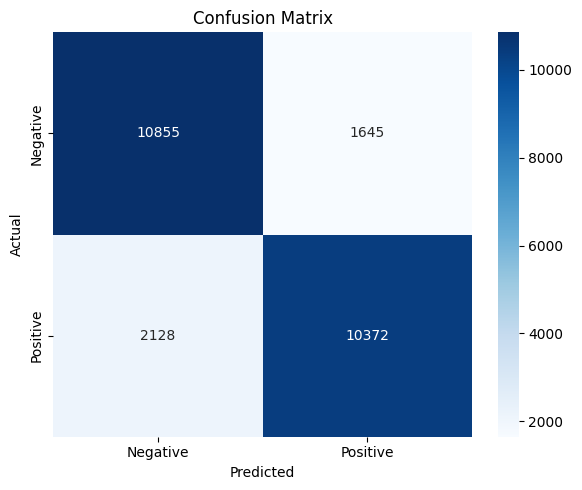

Saved: confusion_matrix.png


In [14]:
# ── 7. Training Curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="Train Acc")
axes[0].plot(history.history["val_accuracy"], label="Val Acc")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved: training_curves.png")

# ── 8. Confusion Matrix & Classification Report ──────────────
y_true, y_pred = [], []
for text_batch, label_batch in test_ds:
    preds = model.predict(text_batch, verbose=0)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(label_batch.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix"); plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

In [15]:
# ── 9. Predict on New Reviews ────────────────────────────────
# Build an end-to-end model that includes the vectorisation layer
export_model = keras.Sequential([
    vectorize_layer,
    model,
    layers.Activation("linear"),   # no-op, keeps output as-is
])

export_model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer="adam",
    metrics=["accuracy"],
)

In [16]:
sample_reviews = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Waste of time. Boring and predictable.",
    "It was okay, not great but not terrible either.",
    "One of the best movies I have ever seen. Highly recommended!",
    "I couldn't even finish watching it. Very disappointing.",
]

predictions = export_model.predict(sample_reviews)
print("\n── Predictions on New Reviews ──")
for review, score in zip(sample_reviews, predictions):
    sentiment = "POSITIVE 😊" if score[0] > 0.5 else "NEGATIVE 😞"
    print(f"[{score[0]:.2f}] {sentiment} → {review[:60]}...")

1/1 [==============================] - 1s 849ms/step

── Predictions on New Reviews ──
[0.98] POSITIVE 😊 → This movie was absolutely fantastic! The acting was superb....
[0.01] NEGATIVE 😞 → Terrible film. Waste of time. Boring and predictable....
[0.01] NEGATIVE 😞 → It was okay, not great but not terrible either....
[0.99] POSITIVE 😊 → One of the best movies I have ever seen. Highly recommended!...
[0.01] NEGATIVE 😞 → I couldn't even finish watching it. Very disappointing....


In [17]:
def predict_sentiment(review_text):
    prediction = export_model.predict([review_text], verbose=0)[0][0]
    confidence  = prediction if prediction > 0.5 else 1 - prediction
    sentiment   = "POSITIVE" if prediction > 0.5 else "NEGATIVE"
    print(f"\nReview   : {review_text[:80]}...")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence * 100:.1f}%")
    print(f"Raw score : {prediction:.4f}  (>0.5 = positive, <0.5 = negative)")
    print("-" * 60)
    return sentiment, confidence

sample_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me hooked.",
    "This movie was not good",
    "This movie was good, not bad",
]

print("\n" + "="*60)
print("         SENTIMENT PREDICTION WITH CONFIDENCE SCORES")
print("="*60)

for review in sample_reviews:
    predict_sentiment(review)

print("\n" + "="*60)
print("        INTERACTIVE PREDICTION — type your own review")
print("="*60)

while True:
    user_input = input("\nEnter a movie review (or type 'quit' to exit):\n> ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Exiting interactive mode.")
        break
    if len(user_input.strip()) == 0:
        print("Please enter some text.")
        continue
    predict_sentiment(user_input)


         SENTIMENT PREDICTION WITH CONFIDENCE SCORES

Review   : This movie was absolutely fantastic! The acting was superb and the story kept me...
Sentiment: POSITIVE
Confidence: 99.2%
Raw score : 0.9919  (>0.5 = positive, <0.5 = negative)
------------------------------------------------------------

Review   : This movie was not good...
Sentiment: NEGATIVE
Confidence: 74.4%
Raw score : 0.2563  (>0.5 = positive, <0.5 = negative)
------------------------------------------------------------

Review   : This movie was good, not bad...
Sentiment: NEGATIVE
Confidence: 98.7%
Raw score : 0.0130  (>0.5 = positive, <0.5 = negative)
------------------------------------------------------------

        INTERACTIVE PREDICTION — type your own review

Review   : quite...
Sentiment: NEGATIVE
Confidence: 75.6%
Raw score : 0.2439  (>0.5 = positive, <0.5 = negative)
------------------------------------------------------------
Exiting interactive mode.


In [18]:
# ── 10. Save Model ───────────────────────────────────────────
model.save("sentiment_model.keras")
print("\nModel saved as: sentiment_model.keras")

# To reload later:
# loaded = keras.models.load_model("sentiment_model.keras")


Model saved as: sentiment_model.keras


In [19]:
# ── Save vocabulary for predict.py ───────────────────────────
import pickle

vocab = vectorize_layer.get_vocabulary()
with open("vectorizer_vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

print(f"Vocabulary saved! Total words: {len(vocab)}")

Vocabulary saved! Total words: 10000
